In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\om\Downloads\archive\sales_data.csv")

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [6]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [7]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Product_ID              0.0
Sale_Date               0.0
Sales_Rep               0.0
Region                  0.0
Sales_Amount            0.0
Quantity_Sold           0.0
Product_Category        0.0
Unit_Cost               0.0
Unit_Price              0.0
Customer_Type           0.0
Discount                0.0
Payment_Method          0.0
Sales_Channel           0.0
Region_and_Sales_Rep    0.0
dtype: float64

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1000, 14)


In [11]:
df.dtypes

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

In [12]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

print("Sale_Date converted successfully!")

Sale_Date converted successfully!


In [13]:
df['Sale_Date'].dtype

dtype('<M8[ns]')

In [14]:
df.describe()

,Product_ID,Sale_Date,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,2023-07-02 17:42:43.199999744,5019.265230,25.355000,2475.304550,2728.440120,0.15239
min,1001.000000,2023-01-01 00:00:00,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2023-03-30 00:00:00,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,2023-06-30 12:00:00,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,2023-10-12 00:00:00,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,2024-01-01 00:00:00,9989.040000,49.000000,4995.300000,5442.150000,0.30000
std,29.573505,NaN,2846.790126,14.159006,1417.872546,1419.399839,0.08720


In [15]:
df.describe(include='object')

,Sales_Rep,Region,Product_Category,Customer_Type,Payment_Method,Sales_Channel,Region_and_Sales_Rep
count,1000,1000,1000,1000,1000,1000,1000
unique,5,4,4,2,3,2,20
top,David,North,Clothing,New,Credit Card,Retail,North-Eve
freq,222,267,268,504,345,512,64


In [16]:
for column in df.select_dtypes(include='object').columns:
    print("\n", column)
    print(df[column].unique())


 Sales_Rep
['Bob' 'David' 'Charlie' 'Eve' 'Alice']

 Region
['North' 'West' 'South' 'East']

 Product_Category
['Furniture' 'Food' 'Clothing' 'Electronics']

 Customer_Type
['Returning' 'New']

 Payment_Method
['Cash' 'Bank Transfer' 'Credit Card']

 Sales_Channel
['Online' 'Retail']

 Region_and_Sales_Rep
['North-Bob' 'West-Bob' 'South-David' 'South-Bob' 'East-Charlie'
 'West-Charlie' 'South-Eve' 'North-Eve' 'West-Eve' 'South-Alice'
 'South-Charlie' 'North-David' 'East-Bob' 'West-David' 'East-Eve'
 'North-Alice' 'East-David' 'West-Alice' 'East-Alice' 'North-Charlie']


In [17]:
for column in df.select_dtypes(include='object').columns:
    print(column, ":", df[column].nunique())

Sales_Rep : 5
Region : 4
Product_Category : 4
Customer_Type : 2
Payment_Method : 3
Sales_Channel : 2
Region_and_Sales_Rep : 20


In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']


In [19]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [20]:
print("Negative Sales Amount:")
print((df['Sales_Amount'] < 0).sum())

print("\nNegative Quantity:")
print((df['Quantity_Sold'] < 0).sum())

print("\nNegative Unit Cost:")
print((df['Unit_Cost'] < 0).sum())

print("\nNegative Unit Price:")
print((df['Unit_Price'] < 0).sum())

print("\nNegative Discount:")
print((df['Discount'] < 0).sum())

Negative Sales Amount:
0

Negative Quantity:
0

Negative Unit Cost:
0

Negative Unit Price:
0

Negative Discount:
0


In [21]:
df['Discount'].describe()

count    1000.00000
mean        0.15239
std         0.08720
min         0.00000
25%         0.08000
50%         0.15000
75%         0.23000
max         0.30000
Name: Discount, dtype: float64

In [22]:
print(df['Discount'].unique())

[0.09 0.11 0.2  0.02 0.08 0.21 0.14 0.12 0.05 0.13 0.23 0.   0.29 0.18
 0.04 0.1  0.26 0.07 0.06 0.24 0.22 0.03 0.17 0.3  0.28 0.15 0.25 0.19
 0.16 0.27 0.01]


In [23]:
df['Calculated_Sales'] = df['Quantity_Sold'] * df['Unit_Price']

df[['Sales_Amount', 'Calculated_Sales', 'Quantity_Sold', 'Unit_Price']].head(10)

,Sales_Amount,Calculated_Sales,Quantity_Sold,Unit_Price
0,5053.97,4809.96,18,267.22
1,4384.02,71560.48,17,4209.44
2,4631.23,11142.00,30,371.40
3,2167.94,174242.25,39,4467.75
4,3750.20,9005.23,13,692.71
5,3761.15,35408.32,32,1106.51
6,618.31,76098.61,29,2624.09
7,7698.92,182373.90,46,3964.65
8,4223.39,32863.50,30,1095.45
9,8239.58,48282.12,18,2682.34


In [24]:
df['Sales_Difference'] = df['Sales_Amount'] - df['Calculated_Sales']

df['Sales_Difference'].describe()

count      1000.000000
mean     -65310.675480
std       57929.566294
min     -249092.180000
25%     -100801.062500
50%      -49718.650000
75%      -18173.725000
max        8667.510000
Name: Sales_Difference, dtype: float64

In [25]:
df['Year'] = df['Sale_Date'].dt.year
df['Month'] = df['Sale_Date'].dt.month
df['Month_Name'] = df['Sale_Date'].dt.month_name()
df['Quarter'] = df['Sale_Date'].dt.quarter
df['Day'] = df['Sale_Date'].dt.day
df['Day_Name'] = df['Sale_Date'].dt.day_name()

In [26]:
df[['Sale_Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_Name']].head()

,Sale_Date,Year,Month,Month_Name,Quarter,Day_Name
0,2023-02-03,2023,2,February,1,Friday
1,2023-04-21,2023,4,April,2,Friday
2,2023-09-21,2023,9,September,3,Thursday
3,2023-08-24,2023,8,August,3,Thursday
4,2023-03-24,2023,3,March,1,Friday


In [27]:
df['Revenue'] = df['Sales_Amount']

In [28]:
df['Total_Cost'] = df['Unit_Cost'] * df['Quantity_Sold']

In [29]:
df['Profit'] = df['Revenue'] - df['Total_Cost']

In [31]:
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100

In [32]:
df[['Revenue', 'Total_Cost', 'Profit', 'Profit_Margin']].head()

,Revenue,Total_Cost,Profit,Profit_Margin
0,5053.97,2749.50,2304.47,45.597224
1,4384.02,64878.63,-60494.61,-1379.889006
2,4631.23,7846.80,-3215.57,-69.432311
3,2167.94,168871.17,-166703.23,-7689.476185
4,3750.20,8285.81,-4535.61,-120.943150


In [33]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,...,Year,Month,Month_Name,Quarter,Day,Day_Name,Revenue,Total_Cost,Profit,Profit_Margin
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,...,2023,2,February,1,3,Friday,5053.97,2749.50,2304.47,45.597224
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,...,2023,4,April,2,21,Friday,4384.02,64878.63,-60494.61,-1379.889006
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,...,2023,9,September,3,21,Thursday,4631.23,7846.80,-3215.57,-69.432311
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,...,2023,8,August,3,24,Thursday,2167.94,168871.17,-166703.23,-7689.476185
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,...,2023,3,March,1,24,Friday,3750.20,8285.81,-4535.61,-120.943150


In [34]:
total_revenue = df['Revenue'].sum()
total_cost = df['Total_Cost'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity_Sold'].sum()
average_order_value = df['Revenue'].mean()

print("Total Revenue:", total_revenue)
print("Total Cost:", total_cost)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Average Sales Amount:", average_order_value)

Total Revenue: 5019265.2299999995
Total Cost: 63842093.64
Total Profit: -58822828.41
Total Quantity Sold: 25355
Average Sales Amount: 5019.265229999999


In [35]:
overall_profit_margin = (total_profit / total_revenue) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Overall Profit Margin: -1171.94 %


In [36]:
category_sales = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

category_sales

Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Revenue, dtype: float64

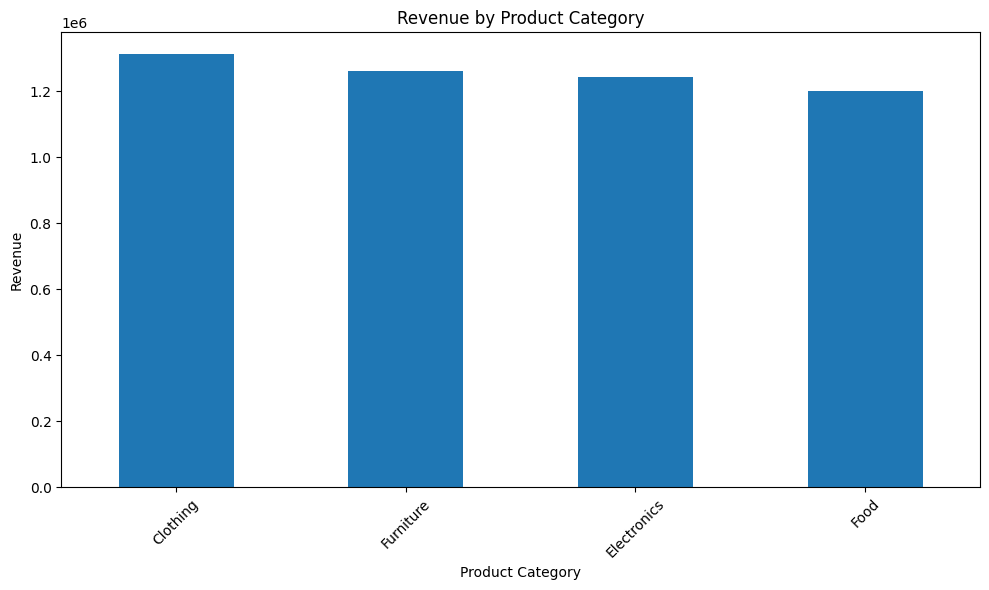

In [37]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

region_sales

Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Revenue, dtype: float64

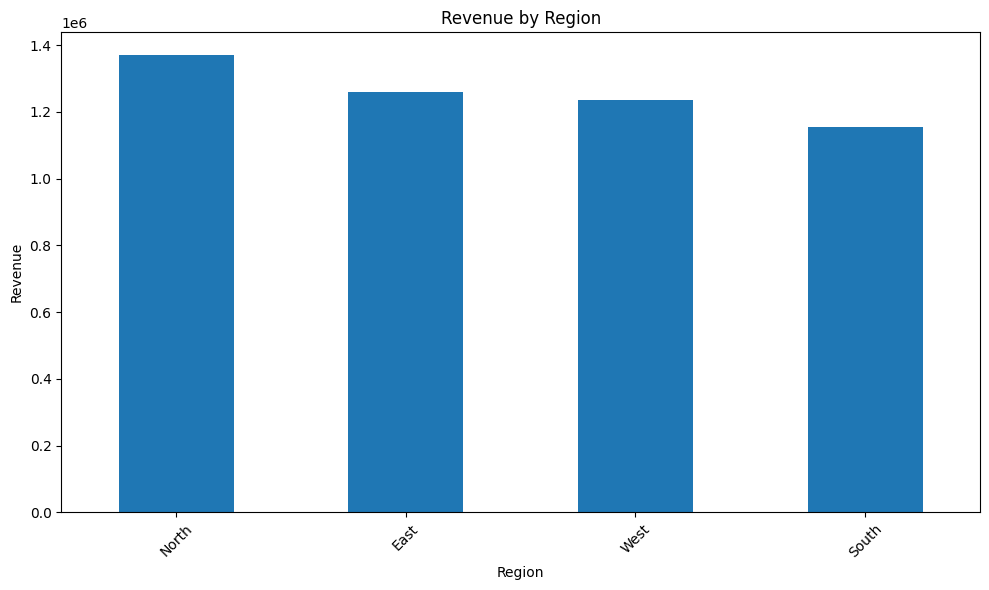

In [39]:
plt.figure(figsize=(10, 6))

region_sales.plot(kind='bar')

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [40]:
rep_sales = df.groupby('Sales_Rep')['Revenue'].sum().sort_values(ascending=False)

rep_sales

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Revenue, dtype: float64

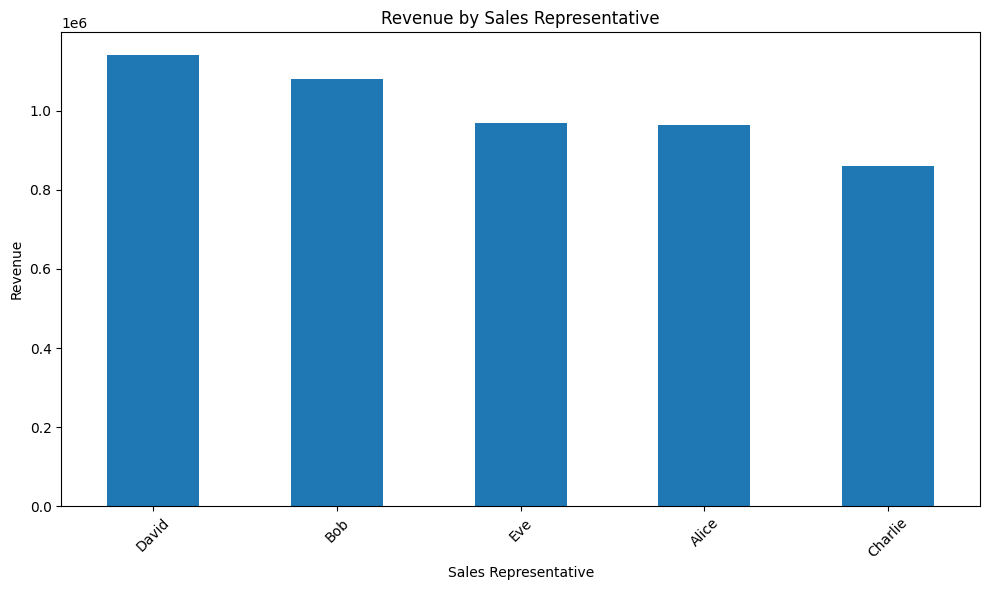

In [41]:
plt.figure(figsize=(10, 6))

rep_sales.plot(kind='bar')

plt.title('Revenue by Sales Representative')
plt.xlabel('Sales Representative')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [42]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Revenue, dtype: float64

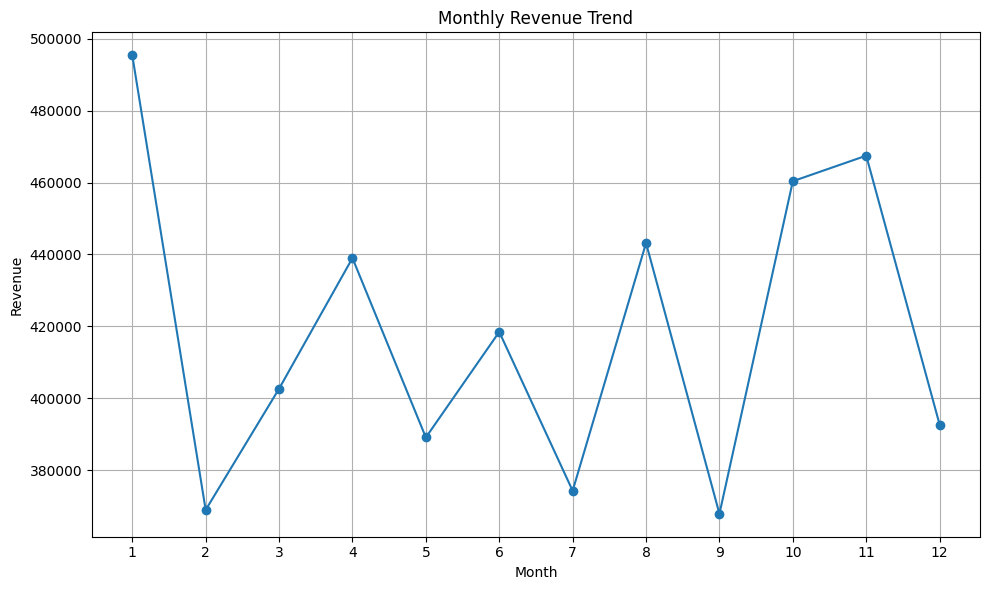

In [43]:
plt.figure(figsize=(10, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))

plt.grid(True)
plt.tight_layout()

plt.show()

In [44]:
customer_sales = df.groupby('Customer_Type')['Revenue'].sum().sort_values(ascending=False)

customer_sales

Customer_Type
Returning    2513006.93
New          2506258.30
Name: Revenue, dtype: float64

In [45]:
channel_sales = df.groupby('Sales_Channel')['Revenue'].sum().sort_values(ascending=False)

channel_sales

Sales_Channel
Retail    2560431.30
Online    2458833.93
Name: Revenue, dtype: float64

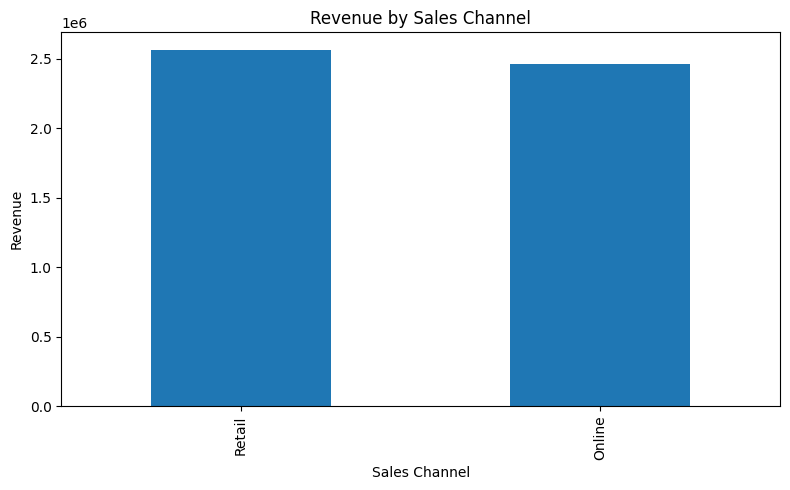

In [46]:
plt.figure(figsize=(8, 5))

channel_sales.plot(kind='bar')

plt.title('Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

In [47]:
payment_counts = df['Payment_Method'].value_counts()

payment_counts

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

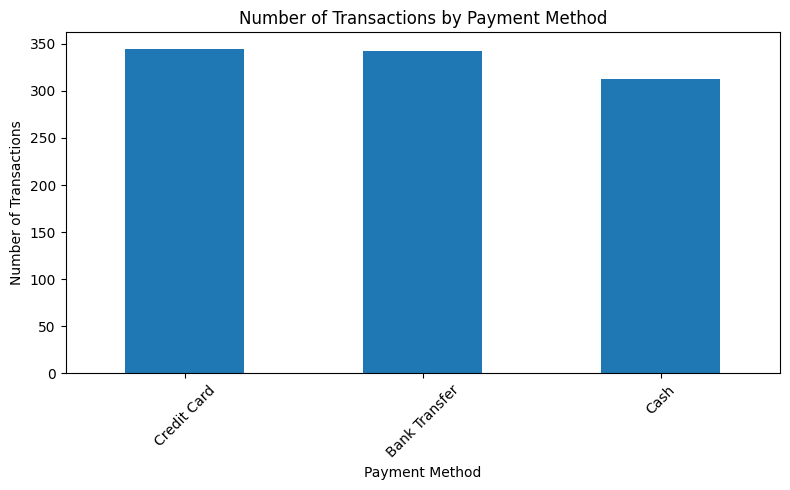

In [48]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.title('Number of Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [49]:
top_products = (
    df.groupby('Product_ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product_ID
1099    101773.87
1092     90615.62
1033     89130.41
1090     88043.25
1086     82269.71
1089     82055.13
1048     81496.82
1001     81017.34
1062     76696.76
1024     75136.67
Name: Revenue, dtype: float64

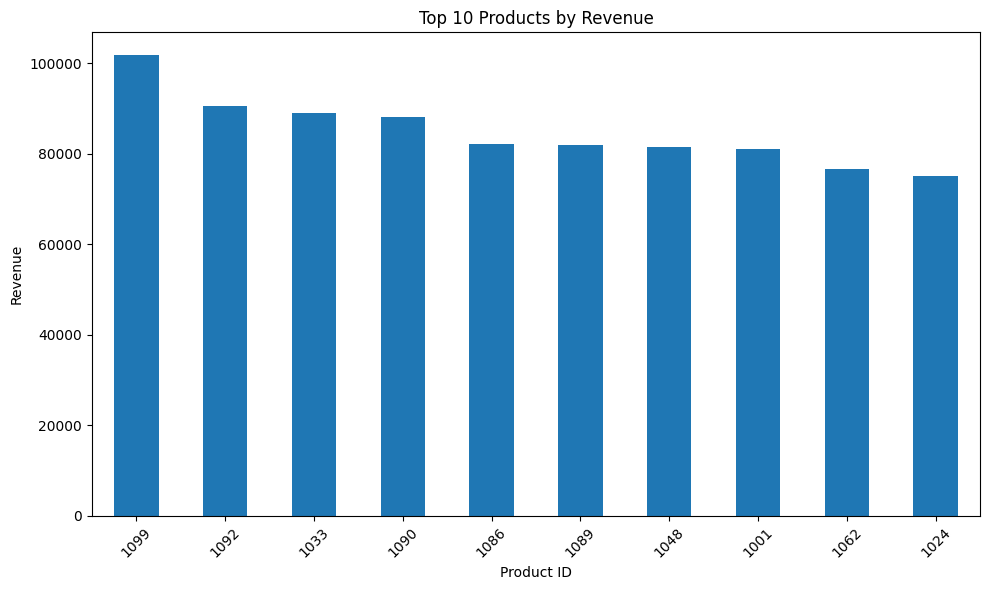

In [50]:
plt.figure(figsize=(10, 6))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [51]:
category_profit = (
    df.groupby('Product_Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

category_profit

Product_Category
Food          -12519004.06
Electronics   -14753220.87
Furniture     -15290301.71
Clothing      -16260301.77
Name: Profit, dtype: float64

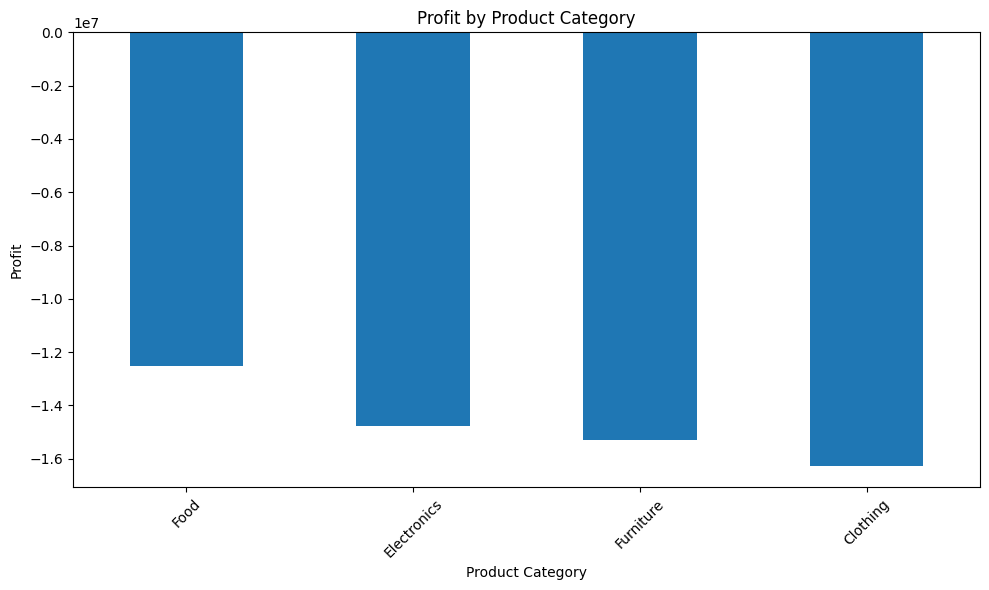

In [52]:
plt.figure(figsize=(10, 6))

category_profit.plot(kind='bar')

plt.title('Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [53]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Calculated_Sales,Sales_Difference,Year,Month,Quarter,Day,Revenue,Total_Cost,Profit,Profit_Margin
Product_ID,1.000000,0.010221,0.094479,0.013402,0.015116,-0.022097,0.073406,-0.072718,0.026981,0.054336,0.060844,-0.064096,0.010221,0.070006,-0.069293,-0.021030
Sales_Amount,0.010221,1.000000,-0.041599,0.009770,0.011812,0.023153,-0.026811,0.075886,0.027441,-0.006813,0.004471,0.025298,1.000000,-0.027276,0.078451,0.335003
Quantity_Sold,0.094479,-0.041599,1.000000,0.053888,0.057296,-0.007806,0.705178,-0.705442,0.001208,-0.019017,-0.023965,0.003047,-0.041599,0.670130,-0.670445,-0.199071
Unit_Cost,0.013402,0.009770,0.053888,1.000000,0.995056,-0.017741,0.653113,-0.650984,-0.074658,-0.049059,-0.044337,0.039580,0.009770,0.682131,-0.679781,-0.217761
Unit_Price,0.015116,0.011812,0.057296,0.995056,1.000000,-0.017027,0.656667,-0.654429,-0.072656,-0.047530,-0.043256,0.037895,0.011812,0.679205,-0.676758,-0.217823
Discount,-0.022097,0.023153,-0.007806,-0.017741,-0.017027,1.000000,-0.014664,0.015765,0.027867,0.002530,0.005010,-0.000944,0.023153,-0.013336,0.014487,0.035782
Calculated_Sales,0.073406,-0.026811,0.705178,0.653113,0.656667,-0.014664,1.000000,-0.998793,-0.047714,-0.048457,-0.048816,0.015387,-0.026811,0.996259,-0.994932,-0.318175
Sales_Difference,-0.072718,0.075886,-0.705442,-0.650984,-0.654429,0.015765,-0.998793,1.000000,0.048942,0.048000,0.048912,-0.014105,0.075886,-0.995084,0.996275,0.333835
Year,0.026981,0.027441,0.001208,-0.074658,-0.072656,0.027867,-0.047714,0.048942,1.000000,-0.085325,-0.072448,-0.093353,0.027441,-0.050792,0.052060,0.016316
Month,0.054336,-0.006813,-0.019017,-0.049059,-0.047530,0.002530,-0.048457,0.048000,-0.085325,1.000000,0.973130,0.064270,-0.006813,-0.050554,0.050068,-0.029330


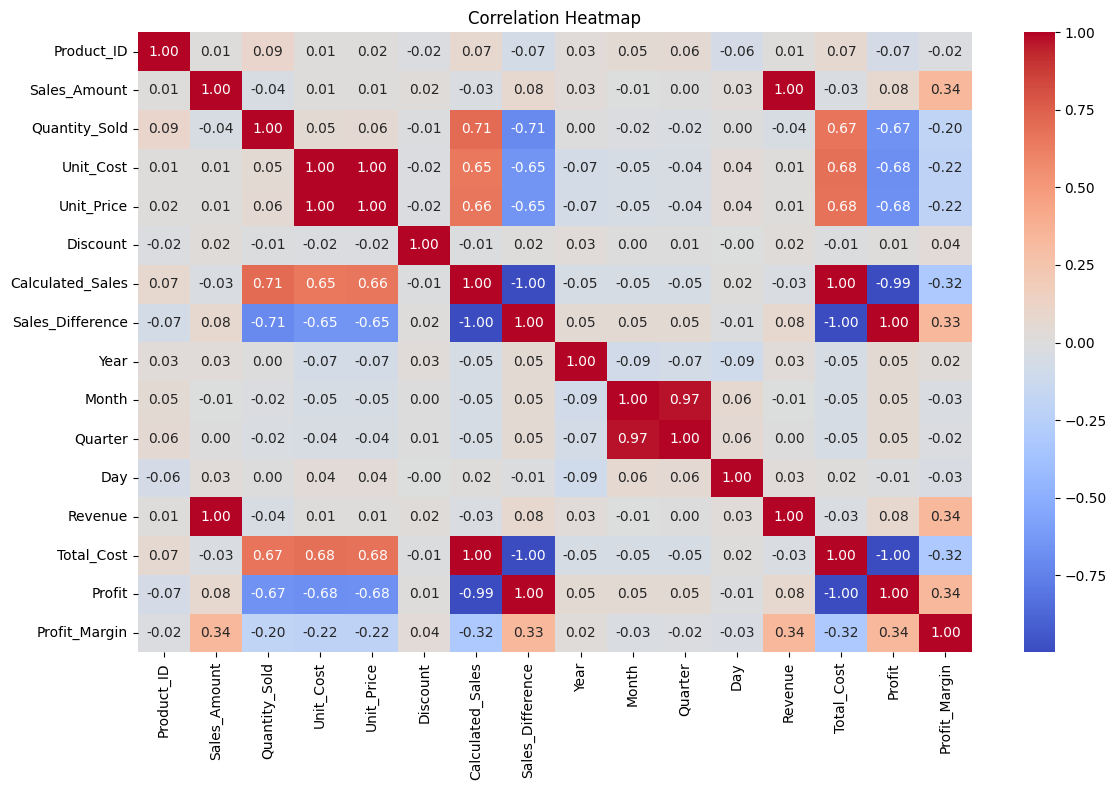

In [54]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

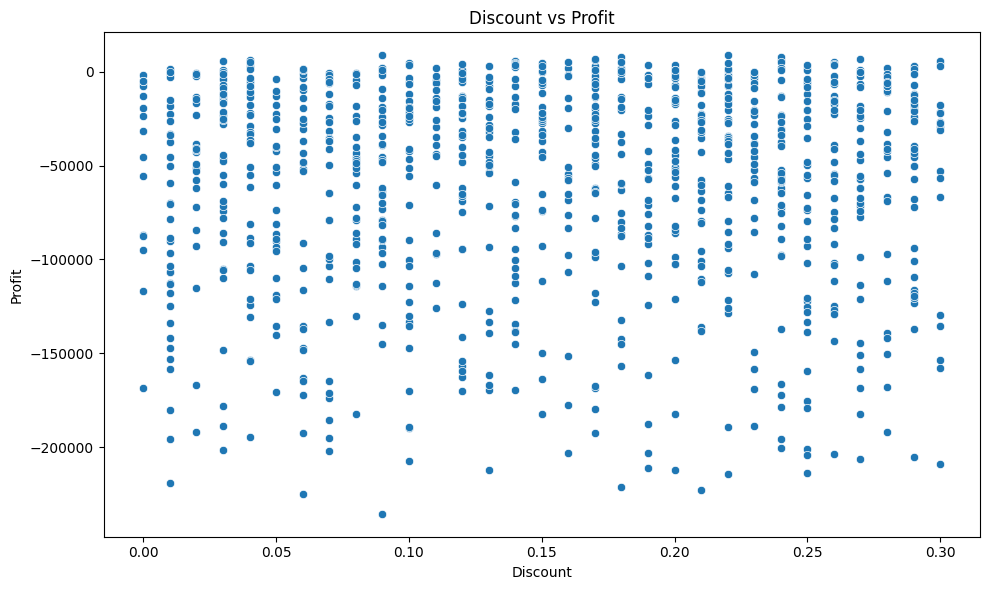

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

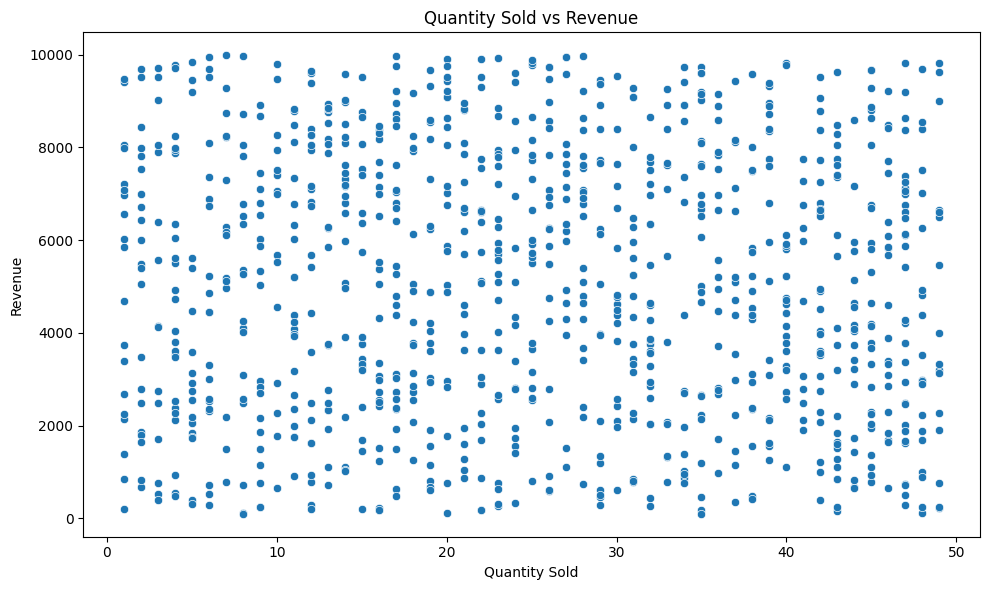

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Quantity_Sold',
    y='Revenue'
)

plt.title('Quantity Sold vs Revenue')
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

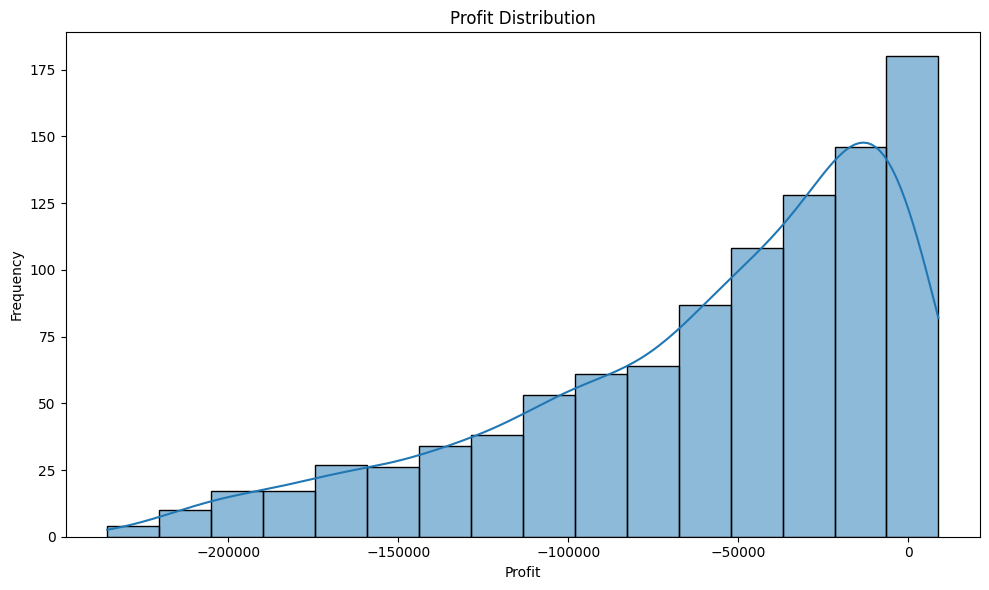

In [57]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Profit'],
    kde=True
)

plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [58]:
df.to_csv('sales_data_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
